# Homework 1: Approximating hard integrals

Evaluation criteria

* correctness
* tests
* code quality (good variable and function names)
* efficiency (use numpy wisely, avoid python for loops)
* good comments / documentation
* flexibility (there should be only 1 implementation, no extra cases inside)
* lack of redundancy (no copy-pasting)

### Task 0: Sketch

convert your implementation of 'integrate' from HW0 to numpy, and modify if needed
write you first sketch of an implementation using numpy.

In [1]:
import numpy as np
def integrate_sketch(fun , aa, bb, number_of_things):
    '''
    >> your description of the function and arguments goes here.
    make an array of n points
    1. compute dx
    2. make an array of indices
    3. compute midpoint xk_star
    4. evaluate f(xk_star)
    5. sum 
    6. multiple sum by dx

    n = number_of_things
    dx = (bb - aa) / n
    k = [0, 1, 2, ..., n-1]
    xk_star = a + (k + 0.5) * dx
    y = [f(x0), f(x1),... ]

    '''

### Task 1: Proper implementation
work on your implmentation, update it using information from Task 2, 3, and 4, 5

In [24]:
%%file integrate_library.py
import numpy as np


def integrate(function_to_integrate, from_x, to_x, num_elements):
    n = num_elements
    a = from_x
    b = to_x

    dx = (b - a) / n
    xk_star = np.linspace(a, b, n, endpoint=False) + dx/2
    f_xk_star = function_to_integrate(xk_star)
    sum = np.sum(f_xk_star) * dx
    return sum

Writing integrate_library.py


In [25]:
!cat integrate_library.py

import numpy as np


def integrate(function_to_integrate, from_x, to_x, num_elements):
    n = num_elements
    a = from_x
    b = to_x

    dx = (b - a) / n
    xk_star = np.linspace(a, b, n, endpoint=False) + dx/2
    f_xk_star = function_to_integrate(xk_star)
    sum = np.sum(f_xk_star) * dx
    return sum


### Task 2: Correctness
write unit tests for your final implementation, and run them using pytest, using the examples from HW0 and one new example mentioned above.

for each case, verify that |res-correct| < 10^-5. you can use function below.
below add unit tests that if your results are close to the correct values. you can use the provided function.

In [26]:
%%file test_integrate.py
import numpy as np
from integrate_library import integrate

'''IMPORTANT TIP, PLEASE READ! This is useful for the last example.
A function taking a vector of values and returning 1 will *not* return a vector,
but rather a single number. This function solves this silly problem,
and you should use it.
'''
# functions
def constant_function_of_one(x):
    '''Evaluates a constant function returning 1.
    It handles both a single number and np.array as input.

    Args:
      x: either a float or np.array of length n
    Returns:
      either a single 1. (as a float) or a length-n np.array of 1.
    '''
    return 0 * x + 1.

def close_enough(a, b, num_digits):
  return np.abs(a-b) < 10**-num_digits

def f1(x):
  value = np.cos(x) / (1 + 2*np.cos(x))
  return np.arccos(value)

def f2(x):
  value = np.cosh(x)
  return value

def f3(x):
  value = 1 / x
  return value

def extra_case(x):
  value = np.log(x-(x**2))
  return value

# tests
def test_f1():
  cor1 = 5/24 * (np.pi**2)
  res1 = (integrate(f1, 0, np.pi/2, 1000))
  assert close_enough(res1, cor1, num_digits=5)

def test_f2():
  cor2 = (np.e**np.e - np.e**-np.e) / 2
  res2 = integrate(f2, 0, np.e, 1000)
  assert close_enough(res2, cor2, num_digits=5)

def test_f3():
  cor3 = 1.0
  res3 = (integrate(f3, 1.0, np.e, 1000))
  assert close_enough(res3, cor3, num_digits=5)

def test_constant():
  cor4 = 1.0
  res4 = (integrate(constant_function_of_one, 0, 1.0, 1000))
  assert close_enough(res4, cor4, num_digits=5)

def test_extra():
  cor5 = -2.0
  res5 = (integrate(extra_case, 0, 1.0, 100000))
  assert close_enough(res5, cor5, num_digits=5)


Overwriting test_integrate.py


In [1]:
!python -m pytest test_integrate.py

============================= test session starts ==============================
platform darwin -- Python 3.11.8, pytest-7.4.0, pluggy-1.0.0
rootdir: /Users/laurensong/Desktop/school/MAS4115
plugins: anyio-4.2.0
collected 5 items                                                              

test_integrate.py .....                                                  [100%]

============================== 5 passed in 0.13s ===============================


In [6]:
# your code for each test-case using the above function
# save it to file and run using pytest as we did in class

# note that you can save your implementation to a file and import your function,
# so you MUST NOT copy-paste it!

### Task 3: Efficiency

run your 'integrate' functions on the second example (with cosh) using n = 10^7 samples. A good implementation using numpy should take around 0.25s = 250ms. 
if it's slower go back, re-test, and re-time.

In [2]:
%%timeit

import numpy as np
from integrate_func import integrate

def f2(x):
    return np.cosh(x)

integrate(f2, 0, np.e, 10_000_000)

63.3 ms ± 4.66 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [7]:
# check how long it took(in seconds)
# added while doing feedback form
from integrate_func import integrate
import time, math

def f2(x):
    return np.cosh(x)

start_time = time.perf_counter()
testing = integrate(f2, 0, math.e, 10_000_000) # with 1000 elements
end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"time: {elapsed_time:.4f} seconds")

time: 0.0921 seconds


### Task 4: Visualization

visualize your approach on the new example.
> you can use plt.bar. check if has some useful parameters. use a resonable small number of elements. make sure it's clear the bars do note overlap

/Users/laurensong/Desktop/school/MAS4115/test_integrate.py:37: RuntimeWarning: invalid value encountered in log
  value = np.log(x-(x**2))


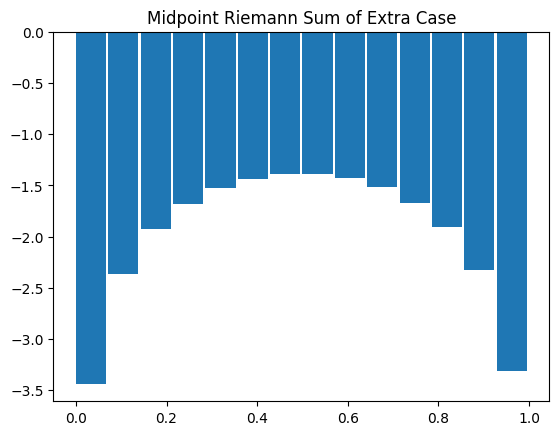

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from test_integrate import extra_case


n = 15
a, b = 0, 1
dx = (b - a) / n
xk_star = np.linspace(a, b, n, endpoint='False') + dx/2

plt.bar(xk_star, extra_case(xk_star), width=dx, align='center')
#plt.xlabel('x')
#plt.ylabel('f(x)')
plt.title('Midpoint Riemann Sum of Extra Case')
plt.show()

### Code quality 

Python coding standard
Python has a coding standard, namely a specific way python code shoud be formatted etc.

See here: https://peps.python.org/pep-0008/

You don't really need to parse this document, we'll use a tool to analyze our code and tell us what's wrong.

Any professional codebase adhers to a coding standard. Contrary to what many beginners tend to think, it is of crucial importance. In the long run unreadable code (as well as untested code) is more of a liability than an asset.

### Linter (flake8)
Below we install a special tool (linter) which will nitpicks about tiny (and larger) details of your code

In [21]:
!pip install flake8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [flake8]


In [5]:
!flake8 integrate_library.py

In [6]:
!flake8 test_integrate.py

test_integrate.py:5:80: E501 line too long (80 > 79 characters)
test_integrate.py:10:1: E302 expected 2 blank lines, found 0
test_integrate.py:21:1: E302 expected 2 blank lines, found 1
test_integrate.py:22:3: E111 indentation is not a multiple of 4
test_integrate.py:24:1: E302 expected 2 blank lines, found 1
test_integrate.py:25:3: E111 indentation is not a multiple of 4
test_integrate.py:26:3: E111 indentation is not a multiple of 4
test_integrate.py:28:1: E302 expected 2 blank lines, found 1
test_integrate.py:29:3: E111 indentation is not a multiple of 4
test_integrate.py:30:3: E111 indentation is not a multiple of 4
test_integrate.py:32:1: E302 expected 2 blank lines, found 1
test_integrate.py:33:3: E111 indentation is not a multiple of 4
test_integrate.py:34:3: E111 indentation is not a multiple of 4
test_integrate.py:36:1: E302 expected 2 blank lines, found 1
test_integrate.py:37:3: E111 indentation is not a multiple of 4
test_integrate.py:38:3: E111 indentation is not a multiple